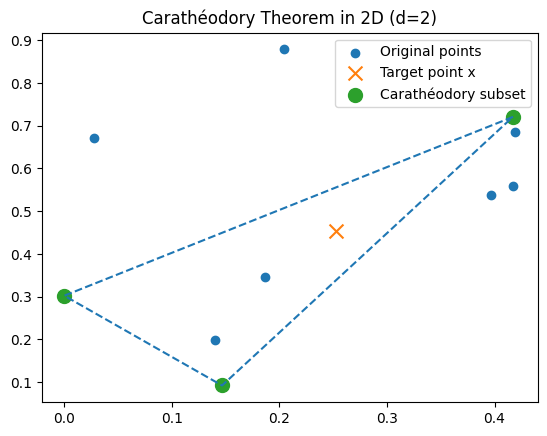

In [4]:
import numpy as np
import itertools
import matplotlib.pyplot as plt

# Settings
np.random.seed(1)
n = 10   # number of points
d = 2    # dimension

# Generate random points in 2D
S = np.random.rand(n, d)

# Create a random convex combination of all points to form x
lam = np.random.rand(n)
lam /= lam.sum()
x = lam @ S

# Find a subset of at most d+1 = 3 points that also generate x
for comb in itertools.combinations(range(n), d+1):
    pts = S[list(comb)]
    # Build system: w1*p1 + w2*p2 + w3*p3 = x, w1+w2+w3=1
    A = np.vstack([pts.T, np.ones(d+1)])
    b = np.append(x, 1)
    try:
        w = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        continue
    if np.all(w >= -1e-8):  # allow tiny negative tolerance
        chosen = comb
        weights = w
        break

# Visualization
plt.figure()
plt.scatter(S[:, 0], S[:, 1], label="Original points")
plt.scatter(x[0], x[1], marker='x', s=100, label="Target point x")
triangle = S[list(chosen)]
plt.scatter(triangle[:, 0], triangle[:, 1], marker='o', s=100, label="Carathéodory subset")
# Draw triangle
plt.plot(np.append(triangle[:,0], triangle[0,0]), 
         np.append(triangle[:,1], triangle[0,1]), linestyle='--')
plt.legend()
plt.title("Carathéodory Theorem in 2D (d=2)")

plt.show()


## Illustration of a convex function
$$
  f\bigl(\lambda x + (1-\lambda)\,y\bigr)
  \le \lambda\,f(x) + (1-\lambda)\,f(y),
  \quad \forall\,x,y \in C,\;\forall\,\lambda \in [0,1].
$$

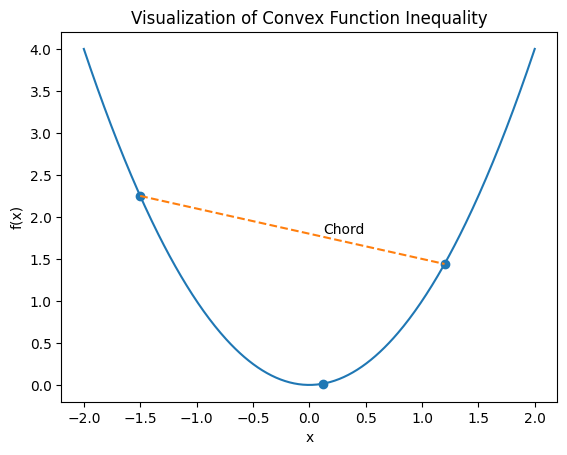

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define a simple convex function
def f(x):
    return x**2

# Generate points for plotting the function
x = np.linspace(-2, 2, 400)
y = f(x)

# Choose two points x1, x2 on the domain
x1, x2 = -1.5, 1.2
y1, y2 = f(x1), f(x2)

# Choose a lambda for the convex combination
lam = 0.4
x_mix = lam * x1 + (1 - lam) * x2
y_mix = f(x_mix)
y_chord = lam * y1 + (1 - lam) * y2

# Plot
plt.figure()
plt.plot(x, y)  # graph of the convex function
plt.plot([x1, x2], [y1, y2], linestyle='--')  # chord between (x1, f(x1)) and (x2, f(x2))
plt.scatter([x1, x2, x_mix], [y1, y2, y_mix])  # the two endpoints and the mixed point
plt.text(x_mix, y_chord, 'Chord', va='bottom')
plt.title('Visualization of Convex Function Inequality')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()


In [8]:
import math

# our convex function
def f(x):
    return x**2

# two sample inputs
x1, x2 = 1.0, 12.0
f1, f2 = f(x1), f(x2)

# mixing weight
lam = 0.25     # in [0,1]
mix_x = lam*x1 + (1-lam)*x2

# left- and right-hand sides of the convexity test
lhs = f(mix_x)
rhs = lam*f1 + (1-lam)*f2

print(f"f({x1}) = {f1:.2f}")
print(f"f({x2}) = {f2:.2f}")
print(f"mix_x = {mix_x:.2f}")
print(f"f(mix_x) = {lhs:.2f}")
print(f"lam*f1 + (1-lam)*f2 = {rhs:.2f}")

assert lhs <= rhs, "Failed convexity test!"

print("✅ Convexity inequality holds: f(mix_x) ≤ lam*f1 + (1-lam)*f2")


f(1.0) = 1.00
f(12.0) = 144.00
mix_x = 9.25
f(mix_x) = 85.56
lam*f1 + (1-lam)*f2 = 108.25
✅ Convexity inequality holds: f(mix_x) ≤ lam*f1 + (1-lam)*f2


In [1]:
from scipy.optimize import linprog

# cost vector
c = [2, 3]

# equality constraint: w1 + w2 = 10
A_eq = [[1, 1]]
b_eq = [10]

# bounds: w1,w2 >= 0
bounds = [(0, None), (0, None)]

res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

print("Status:", res.message)
print("Optimal w:", res.x)
print("Optimal cost:", res.fun)

# If you want the dual variables (λ for the equality constraint):
print("Dual for Aw=b (lambda):", res.eqlin.marginals)


Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimal w: [10.  0.]
Optimal cost: 20.0
Dual for Aw=b (lambda): [2.]


In [6]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.optim import Adam

# 1) A toy model
def model(x=None):
    z = numpyro.sample("z", dist.Normal(0., 1.))
    numpyro.sample("x", dist.Normal(z, 1.), obs=x)

# 2) AutoNormal guide + ELBO + optimizer
guide = AutoNormal(model)
elbo = Trace_ELBO()
optim = Adam(step_size=1e-2)
svi = SVI(model, guide, optim, elbo)

# 3) Hyperparameters for the constraint
ρ = 1.0               # penalty weight
c = 1.0               # desired E_q[z]

# 4) One “augmented” training step
@jax.jit
def constrained_step(svi_state, λ):
    # a) split RNG and grab current params
    rng_key, subkey = jax.random.split(svi_state.rng_key)
    params = svi.get_params(svi_state)

    # b) define the augmented loss (no aux)
    def aug_loss_fn(p):
        base_elbo = elbo.loss(subkey, p, model, guide, x=1.5)
        z_samples = guide.sample_posterior(subkey, p, (128,))["z"]
        m = jnp.mean(z_samples)
        return base_elbo + λ * (m - c) + 0.5 * ρ * (m - c) ** 2

    # c) compute loss and grads
    loss_val, grads = jax.value_and_grad(aug_loss_fn)(params)

    # d) step the optimizer via NumPyro’s wrapper API
    new_opt_state = optim.update(grads, svi_state.optim_state)
    new_params = optim.get_params(new_opt_state)

    # e) build the new SVI state (keep mutable_state and updated RNG)
    new_svi_state = svi_state._replace(
        optim_state=new_opt_state,
        rng_key=rng_key
    )

    # f) dual ascent for λ
    z_samples = guide.sample_posterior(subkey, new_params, (128,))["z"]
    moment = jnp.mean(z_samples)
    new_λ = λ + ρ * (moment - c)

    return new_svi_state, new_λ, loss_val

# 5) Initialize SVI and λ
rng = jax.random.PRNGKey(0)
svi_state = svi.init(rng, x=1.5)
λ = 0.0

# 6) Run training loop
for i in range(1, 1001):
    svi_state, λ, loss = constrained_step(svi_state, λ)
    if i % 200 == 0:
        params = svi.get_params(svi_state)
        eqz = jnp.mean(guide.sample_posterior(rng, params, (128,))["z"])
        print(f"step {i:4d}  loss={loss:.3f}  E_q[z]={eqz:.3f}  λ={λ:.3f}")


step  200  loss=23.080  E_q[z]=0.997  λ=35.632
step  400  loss=4.324  E_q[z]=-0.262  λ=-67.126
step  600  loss=57.054  E_q[z]=1.261  λ=67.431
step  800  loss=67.825  E_q[z]=-1.424  λ=-59.035
step 1000  loss=-39.649  E_q[z]=1.573  λ=-22.283
